In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

In [6]:
def seir_model(y, t, N, A, beta1, beta2, alpha, mu, k, m):
    S, E, I, R = y
    media_factor = beta1 - (beta2 * I) / (alpha + I)

    dSdt = A - media_factor * (S * I / N) - mu * S
    dEdt = media_factor * (S * I / N) - (k + mu) * E
    dIdt = k * E - (m + mu) * I
    dRdt = m * I - mu * R

    return dSdt, dEdt, dIdt, dRdt

In [7]:
N = 10000
I0, E0, R0 = 1, 0, 0
S0 = N - I0 - E0 - R0
y0 = S0, E0, I0, R0

A = 0.1
beta1 = 0.8
beta2 = 0.4
alpha = 10
mu = 0.01
k = 0.1
m = 0.05

t = np.linspace(0, 160, 160)

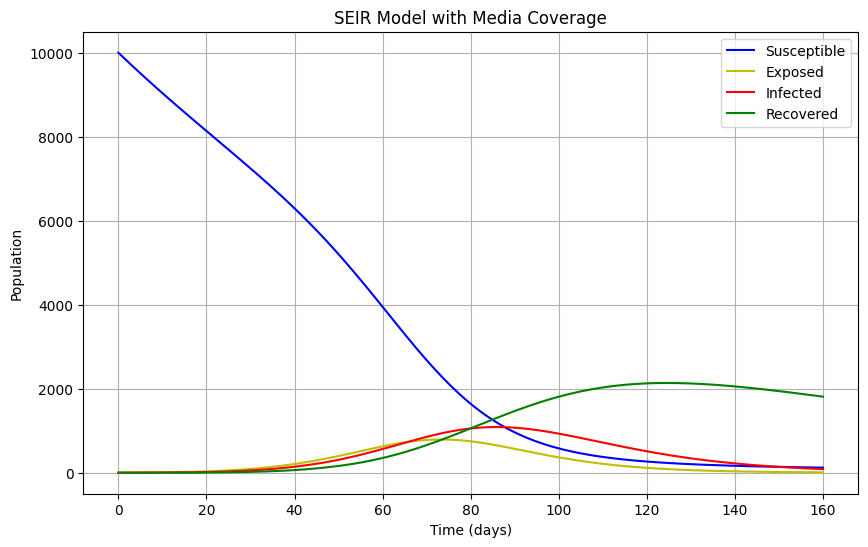

In [8]:
result = odeint(seir_model, y0, t, args=(N, A, beta1, beta2, alpha, mu, k, m))
S, E, I, R = result.T

plt.figure(figsize=(10, 6))
plt.plot(t, S, 'b', label='Susceptible')
plt.plot(t, E, 'y', label='Exposed')
plt.plot(t, I, 'r', label='Infected')
plt.plot(t, R, 'g', label='Recovered')

plt.xlabel('Time (days)')
plt.ylabel('Population')
plt.title('SEIR Model with Media Coverage')
plt.legend()
plt.grid(True)
plt.show()

## Observation
- With beta1 = 0.8, the infection spreads and peaks around day __.
- The Recovered population grows as the Infected population declines.
- This demonstrates the importance of the transmission rate (beta1).